In [1]:
# 데이터 축소
import pandas as pd

import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

In [2]:
# 데이터 불러오기
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species']

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 150, dtype: int64

In [3]:
X = df.drop('species', axis=1)
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [4]:
# 변수의 설명도 출력

# 주성분 수(n_components)가 4를 갖도록 PCA 변환을 수행
pca = PCA(n_components=4)
# PCA 모델 학습
pca.fit(X)
# 변수의 설명도(explained_variance_ratio)를 출력
pca.explained_variance_ratio_

array([0.92461872, 0.05306648, 0.01710261, 0.00521218])

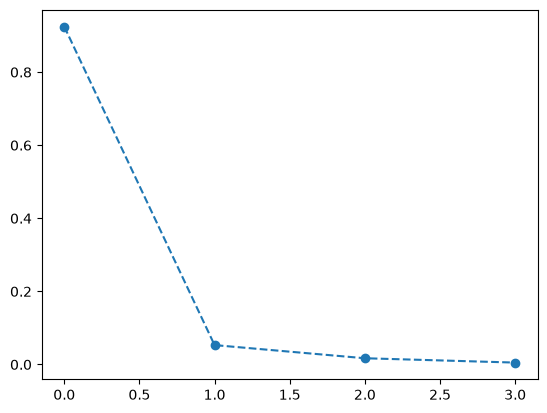

In [ ]:
# PCA 그래프 시각화
# 마커: o(원, circle)
# 선 종류: --(파선, dashed line)
plt.plot(pca.explained_variance_ratio_, 'o--')

In [6]:
# 주성분 수(n_components)가 2를 갖도록 PCA 변환을 수행
pca = PCA(n_components=2)

# PCA 모델 학습
pca_transformed = pca.fit_transform(iris.data)

# 생성된 변수를 각각 데이터프레임 df의 pca_1, pca_2 열에 추가
df['pca_1'] = pca_transformed[:,0]
df['pca_2'] = pca_transformed[:,1]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,pca_1,pca_2
0,5.1,3.5,1.4,0.2,0,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,0,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,0,-2.728717,0.326755


<Axes: xlabel='pca_1', ylabel='pca_2'>

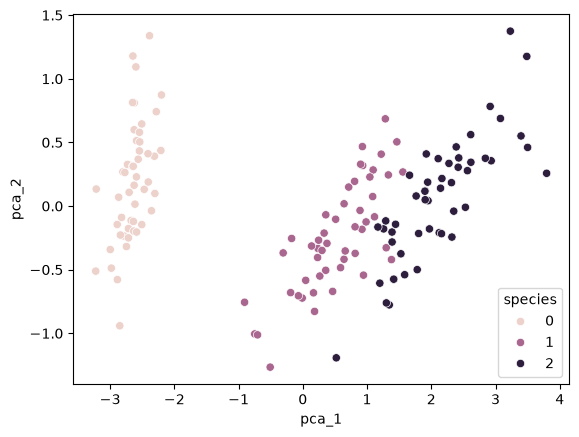

In [ ]:
# 데이터프레임(df)의 pca_1, pca_2 열을 각각 x축, y축으로 설정하고, 'species'에 따라 다른 값을 표시하는 산점도(scatterplot) 그래프 시각화
# legend='auto' (기본값): 상황에 따라 자동으로 범례 표시
# legend='full': 모든 범주/값을 범례에 표시
# legend='brief': 간단한 범례
# legend=False: 범례 표시 안함
sns.scatterplot(x= df['pca_1'], y= df['pca_2'], hue=df['species'])